# New Jersey Home Affordability Analysis: 2015-2025 Period

**Analysis of demographic patterns, gentrification effects, and community degradation across New Jersey municipalities over the past decade**

This notebook analyzes:
- Housing price trends from 2015-2025 (10-year period)
- Demographic shifts and affordability patterns
- Gentrification indicators with specific town examples
- Communities experiencing degradation vs improvement
- Regional contrasts and county-level patterns

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!pip install duckdb python-dotenv pgeocode -q
import duckdb
import pgeocode
from pathlib import Path
import sys

# Use pgeocode for ZIP → coordinates
nomi = pgeocode.Nominatim('us')

# Consistent color palette
PALETTE = {
    'Degrading (Economic Distress)': '#d62728',
    'Middle Class Stable': '#ff7f0e',
    'Gentrifying (High Price Growth)': '#2ca02c'
}
COLORS_LIST = ['#d62728', '#ff7f0e', '#2ca02c']

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)


def find_project_root(start: Path) -> Path:
    for path in [start.resolve(), *start.resolve().parents]:
        if (path / "config.py").exists():
            return path
    raise FileNotFoundError("Could not locate project root containing config.py")


def connect_duckdb() -> duckdb.DuckDBPyConnection:
    project_root = find_project_root(Path.cwd())

    if str(project_root) not in sys.path:
        sys.path.insert(0, str(project_root))

    from config import DB_PATH

    db_path = Path(DB_PATH)
    if not db_path.exists():
        raise FileNotFoundError(f"DuckDB database not found at: {db_path}")

    return duckdb.connect(str(db_path), read_only=True)


conn = connect_duckdb()
print("Connected to DuckDB successfully.")

Connected to DuckDB successfully.


## 1. Load Affordability Data (Last 10 Years: 2015-2025)

In [4]:
# Calculate affordability metrics by zip code (2015-2025)
affordability = conn.execute("""
    WITH latest_zhvi AS (
        SELECT 
            zip_code,
            county,
            date,
            zhvi_usd,
            ROW_NUMBER() OVER (PARTITION BY zip_code ORDER BY date DESC) as rn
        FROM zillow_home_values
        WHERE zhvi_usd IS NOT NULL
    ),
    baseline_zhvi AS (
        SELECT 
            zip_code,
            zhvi_usd as zhvi_baseline,
            date as baseline_date
        FROM zillow_home_values
        WHERE zhvi_usd IS NOT NULL
            AND date >= '2015-01-01'
            AND date <= '2015-12-31'
        QUALIFY ROW_NUMBER() OVER (PARTITION BY zip_code ORDER BY date ASC) = 1
    )
    SELECT 
        l.zip_code,
        l.county,
        l.zhvi_usd as current_home_value,
        b.zhvi_baseline as baseline_home_value,
        b.baseline_date,
        l.date as latest_date,
        c.income_median_hh,
        c.pop_total,
        c.poverty_rate,
        c.homeownership_rate,
        c.gross_rent_median,
        c.rent_burden_severe_pct,
        c.diversity_index,
        c.pct_bachelors_plus,
        c.acs_year,
        CASE WHEN c.income_median_hh > 0 
             THEN l.zhvi_usd / c.income_median_hh 
             ELSE NULL END as price_to_income_ratio,
        ((l.zhvi_usd - b.zhvi_baseline) / b.zhvi_baseline * 100) as price_change_pct,
        (l.zhvi_usd - b.zhvi_baseline) as price_change_usd
    FROM latest_zhvi l
    LEFT JOIN baseline_zhvi b ON l.zip_code = b.zip_code
    LEFT JOIN census_acs c ON l.zip_code = c.zcta AND c.geo_type = 'zcta'
    WHERE l.rn = 1
        AND l.county IS NOT NULL
        AND b.zhvi_baseline IS NOT NULL
    ORDER BY l.county, l.zip_code
""").df()

print(f"\nAffordability data: {len(affordability)} zip codes")
print(f"\nAffordability Metrics Summary (2015-2025):")
print(affordability[['price_to_income_ratio', 'price_change_pct', 'poverty_rate', 'rent_burden_severe_pct']].describe())


Affordability data: 6481 zip codes

Affordability Metrics Summary (2015-2025):
       price_to_income_ratio  price_change_pct  poverty_rate  \
count            6466.000000       6481.000000   6480.000000   
mean                8.205581        101.685829      8.122958   
std                 5.469772         65.631988      7.165916   
min                 2.077173         12.275191      0.000000   
25%                 5.648047         64.661844      3.620000   
50%                 6.934526         82.032029      5.990000   
75%                 8.661345        111.433746      9.760000   
max                72.076745        522.938840     53.650000   

       rent_burden_severe_pct  
count             6437.000000  
mean                24.192175  
std                 11.430801  
min                  0.000000  
25%                 17.330000  
50%                 23.910000  
75%                 30.500000  
max                100.000000  


## 2. Gentrification Analysis

In [5]:
# Identify gentrification indicators
gentrification = affordability.copy()

# Calculate gentrification score (adjusted for 10-year period)
gentrification['gent_score'] = 0

# High price growth (adjusted thresholds for 10 years)
gentrification.loc[gentrification['price_change_pct'] > 50, 'gent_score'] += 2
gentrification.loc[(gentrification['price_change_pct'] > 35) & (gentrification['price_change_pct'] <= 50), 'gent_score'] += 1

# High education levels (indicator of demographic shift)
gentrification.loc[gentrification['pct_bachelors_plus'] > 50, 'gent_score'] += 1

# Low poverty (gentrified areas typically have lower poverty)
gentrification.loc[gentrification['poverty_rate'] < 10, 'gent_score'] += 1

# High price-to-income (decreased affordability)
gentrification.loc[gentrification['price_to_income_ratio'] > 6, 'gent_score'] += 1

# Classify areas
gentrification['gentrification_status'] = 'Stable'
gentrification.loc[gentrification['gent_score'] >= 4, 'gentrification_status'] = 'High Gentrification'
gentrification.loc[(gentrification['gent_score'] >= 2) & (gentrification['gent_score'] < 4), 'gentrification_status'] = 'Moderate Gentrification'

# Summary
gent_summary = gentrification.groupby('gentrification_status').agg({
    'zip_code': 'count',
    'price_change_pct': 'mean',
    'price_to_income_ratio': 'mean',
    'pct_bachelors_plus': 'mean',
    'poverty_rate': 'mean'
}).round(2)

print("\n" + "="*70)
print("GENTRIFICATION ANALYSIS SUMMARY (2015-2025)")
print("="*70)
print(gent_summary)
print("="*70)

# Show specific examples
print("\n📍 HIGH GENTRIFICATION EXAMPLES:")
high_gent = gentrification[gentrification['gentrification_status'] == 'High Gentrification'].sort_values('price_change_pct', ascending=False)
for idx, row in high_gent.head(10).iterrows():
    print(f"  • ZIP {row['zip_code']} ({row['county']}): +{row['price_change_pct']:.1f}% | ${row['current_home_value']:,.0f} | Income ratio: {row['price_to_income_ratio']:.1f}x")

print("\n📍 STABLE COMMUNITIES:")
stable = gentrification[gentrification['gentrification_status'] == 'Stable'].sort_values('price_change_pct')
for idx, row in stable.head(5).iterrows():
    print(f"  • ZIP {row['zip_code']} ({row['county']}): {row['price_change_pct']:+.1f}% | ${row['current_home_value']:,.0f}")


GENTRIFICATION ANALYSIS SUMMARY (2015-2025)
                         zip_code  price_change_pct  price_to_income_ratio  \
gentrification_status                                                        
High Gentrification          3608             91.37                   8.77   
Moderate Gentrification      2806            116.74                   7.54   
Stable                         67             26.68                   5.15   

                         pct_bachelors_plus  poverty_rate  
gentrification_status                                      
High Gentrification                   50.03          4.96  
Moderate Gentrification               29.57         11.98  
Stable                                14.52         17.04  

📍 HIGH GENTRIFICATION EXAMPLES:
  • ZIP 07062 (Union County): +437.6% | $493,221 | Income ratio: 6.1x
  • ZIP 07083 (Union County): +238.8% | $570,864 | Income ratio: 7.0x
  • ZIP 07083 (Union County): +238.8% | $570,864 | Income ratio: 6.3x
  • ZIP 07083 (Union 

In [14]:
# ── Composite Gentrification Score (0–100) ─────────────────────────────────
# Each indicator is percentile-ranked then combined with domain-informed weights.
# Indicators marked _inv are reversed: lower raw value = higher gentrification pressure.
#
# Weights (must sum to 1.0):
#   price_change_pct      0.30  — decade appreciation is the most direct signal
#   pct_bachelors_plus    0.20  — educational influx proxy for demographic shift
#   price_to_income_ratio 0.20  — affordability squeeze
#   poverty_rate (inv)    0.15  — displacement: fewer poor residents post-gentrification
#   homeownership (inv)   0.10  — rising renter share signals displaced owners
#   rent_burden           0.05  — severe cost burden as secondary pressure

GENT_WEIGHTS = {
    'price_change_pct':       0.30,
    'pct_bachelors_plus':     0.20,
    'price_to_income_ratio':  0.20,
    'poverty_rate_inv':       0.15,
    'homeownership_rate_inv': 0.10,
    'rent_burden_severe_pct': 0.05,
}

_required = ['price_change_pct', 'pct_bachelors_plus', 'price_to_income_ratio',
             'poverty_rate', 'homeownership_rate', 'rent_burden_severe_pct']

gent_score_df = (
    affordability
    .dropna(subset=_required)
    .drop_duplicates(subset='zip_code', keep='first')
    .copy()
)

def pct_rank(s):
    return s.rank(pct=True) * 100

gent_score_df['_pr_price_change']  = pct_rank(gent_score_df['price_change_pct'])
gent_score_df['_pr_bachelors']     = pct_rank(gent_score_df['pct_bachelors_plus'])
gent_score_df['_pr_price_income']  = pct_rank(gent_score_df['price_to_income_ratio'])
gent_score_df['_pr_poverty_inv']   = pct_rank(-gent_score_df['poverty_rate'])
gent_score_df['_pr_own_inv']       = pct_rank(-gent_score_df['homeownership_rate'])
gent_score_df['_pr_rent_burden']   = pct_rank(gent_score_df['rent_burden_severe_pct'])

gent_score_df['gentrification_score'] = (
    gent_score_df['_pr_price_change']  * GENT_WEIGHTS['price_change_pct']       +
    gent_score_df['_pr_bachelors']     * GENT_WEIGHTS['pct_bachelors_plus']      +
    gent_score_df['_pr_price_income']  * GENT_WEIGHTS['price_to_income_ratio']   +
    gent_score_df['_pr_poverty_inv']   * GENT_WEIGHTS['poverty_rate_inv']        +
    gent_score_df['_pr_own_inv']       * GENT_WEIGHTS['homeownership_rate_inv']  +
    gent_score_df['_pr_rent_burden']   * GENT_WEIGHTS['rent_burden_severe_pct']
).round(1)

bins   = [0,  40,   60,       75,     90,      100]
labels = ['Low', 'Below Average', 'Moderate', 'High', 'Extreme']
gent_score_df['gent_tier'] = pd.cut(
    gent_score_df['gentrification_score'], bins=bins, labels=labels
)

OUTPUT_COLS = [
    'zip_code', 'county',
    'gentrification_score', 'gent_tier',
    'price_change_pct', 'current_home_value', 'baseline_home_value',
    'price_to_income_ratio', 'pct_bachelors_plus',
    'poverty_rate', 'homeownership_rate', 'rent_burden_severe_pct',
    'income_median_hh',
]

gent_ranked = (
    gent_score_df[OUTPUT_COLS]
    .sort_values('gentrification_score', ascending=False)
    .reset_index(drop=True)
)
gent_ranked.index += 1   # rank starts at 1

print(f"Gentrification score computed for {len(gent_ranked):,} ZIP codes\n")
print("Tier distribution:")
print(gent_ranked['gent_tier'].value_counts().reindex(labels))

print("\n── Top 25 most gentrified ZIP codes ──────────────────────────────────")
pd.set_option('display.float_format', '{:,.1f}'.format)
pd.set_option('display.max_columns', 12)
pd.set_option('display.width', 120)
print(gent_ranked.head(25)[[
    'zip_code', 'county', 'gentrification_score', 'gent_tier',
    'price_change_pct', 'current_home_value', 'price_to_income_ratio',
    'pct_bachelors_plus', 'poverty_rate'
]].to_string())

print("\n── Bottom 10 (lowest gentrification pressure) ────────────────────────")
print(gent_ranked.tail(10)[[
    'zip_code', 'county', 'gentrification_score', 'gent_tier',
    'price_change_pct', 'poverty_rate', 'homeownership_rate'
]].to_string())

gent_ranked

Gentrification score computed for 540 ZIP codes

Tier distribution:
gent_tier
Low              111
Below Average    306
Moderate         110
High              13
Extreme            0
Name: count, dtype: int64

── Top 25 most gentrified ZIP codes ──────────────────────────────────
   zip_code           county  gentrification_score gent_tier  price_change_pct  current_home_value  price_to_income_ratio  pct_bachelors_plus  poverty_rate
1     07711  Monmouth County                  82.9      High             228.0         2,353,569.6                   18.7                59.5           3.2
2     07041     Essex County                  80.8      High             207.5         1,205,070.7                    7.5                75.7           2.9
3     07040     Essex County                  79.4      High             232.5           908,389.8                    8.1                60.8           3.7
4     08730  Monmouth County                  79.2      High             205.0         1,782,40

,zip_code,county,gentrification_score,gent_tier,price_change_pct,current_home_value,...,price_to_income_ratio,pct_bachelors_plus,poverty_rate,homeownership_rate,rent_burden_severe_pct,income_median_hh
1,07711,Monmouth County,82.9,High,228.0,"2,353,569.6",...,18.7,59.5,3.2,75.5,15.3,"126,042.0"
2,07041,Essex County,80.8,High,207.5,"1,205,070.7",...,7.5,75.7,2.9,69.0,20.5,"160,469.0"
3,07040,Essex County,79.4,High,232.5,"908,389.8",...,8.1,60.8,3.7,78.5,31.8,"111,655.0"
4,08730,Monmouth County,79.2,High,205.0,"1,782,409.8",...,17.0,58.5,4.3,90.4,44.1,"104,659.0"
5,07042,Essex County,78.7,High,226.0,"896,043.8",...,11.0,61.1,8.1,45.2,21.0,"81,225.0"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
536,07863,Warren County,21.1,Low,64.6,"386,074.7",...,4.7,23.6,8.9,84.8,11.7,"82,768.0"
537,08001,Salem County,17.2,Low,14.1,"288,309.6",...,2.1,15.8,0.0,96.7,0.0,"138,799.0"
538,08014,Gloucester County,16.7,Low,29.5,"289,191.1",...,2.7,15.1,5.2,75.7,0.0,"107,838.0"
539,08345,Cumberland County,14.5,Low,31.4,"320,262.4",...,5.8,13.6,22.2,91.2,52.0,"54,886.0"


In [15]:
gent_ranked

,zip_code,county,gentrification_score,gent_tier,price_change_pct,current_home_value,...,price_to_income_ratio,pct_bachelors_plus,poverty_rate,homeownership_rate,rent_burden_severe_pct,income_median_hh
1,07711,Monmouth County,82.9,High,228.0,"2,353,569.6",...,18.7,59.5,3.2,75.5,15.3,"126,042.0"
2,07041,Essex County,80.8,High,207.5,"1,205,070.7",...,7.5,75.7,2.9,69.0,20.5,"160,469.0"
3,07040,Essex County,79.4,High,232.5,"908,389.8",...,8.1,60.8,3.7,78.5,31.8,"111,655.0"
4,08730,Monmouth County,79.2,High,205.0,"1,782,409.8",...,17.0,58.5,4.3,90.4,44.1,"104,659.0"
5,07042,Essex County,78.7,High,226.0,"896,043.8",...,11.0,61.1,8.1,45.2,21.0,"81,225.0"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
536,07863,Warren County,21.1,Low,64.6,"386,074.7",...,4.7,23.6,8.9,84.8,11.7,"82,768.0"
537,08001,Salem County,17.2,Low,14.1,"288,309.6",...,2.1,15.8,0.0,96.7,0.0,"138,799.0"
538,08014,Gloucester County,16.7,Low,29.5,"289,191.1",...,2.7,15.1,5.2,75.7,0.0,"107,838.0"
539,08345,Cumberland County,14.5,Low,31.4,"320,262.4",...,5.8,13.6,22.2,91.2,52.0,"54,886.0"


## 3. Community Degradation Analysis

In [6]:
# Identify degrading communities
degradation = affordability.copy()

# Calculate degradation score (adjusted for 10-year period)
degradation['degrad_score'] = 0

# Low/negative price growth (adjusted for 10 years)
degradation.loc[degradation['price_change_pct'] < 15, 'degrad_score'] += 2
degradation.loc[(degradation['price_change_pct'] >= 15) & (degradation['price_change_pct'] < 25), 'degrad_score'] += 1

# High poverty
degradation.loc[degradation['poverty_rate'] > 20, 'degrad_score'] += 2
degradation.loc[(degradation['poverty_rate'] > 15) & (degradation['poverty_rate'] <= 20), 'degrad_score'] += 1

# Severe rent burden
degradation.loc[degradation['rent_burden_severe_pct'] > 25, 'degrad_score'] += 1

# Low homeownership
degradation.loc[degradation['homeownership_rate'] < 40, 'degrad_score'] += 1

# Classify
degradation['degradation_status'] = 'Stable/Growing'
degradation.loc[degradation['degrad_score'] >= 4, 'degradation_status'] = 'High Degradation'
degradation.loc[(degradation['degrad_score'] >= 2) & (degradation['degrad_score'] < 4), 'degradation_status'] = 'Moderate Degradation'

# Summary
degrad_summary = degradation.groupby('degradation_status').agg({
    'zip_code': 'count',
    'price_change_pct': 'mean',
    'poverty_rate': 'mean',
    'rent_burden_severe_pct': 'mean',
    'homeownership_rate': 'mean'
}).round(2)

print("\n" + "="*70)
print("COMMUNITY DEGRADATION ANALYSIS (2015-2025)")
print("="*70)
print(degrad_summary)
print("="*70)

# Show specific examples
print("\n📍 HIGH DEGRADATION EXAMPLES:")
high_degrad = degradation[degradation['degradation_status'] == 'High Degradation'].sort_values('poverty_rate', ascending=False)
for idx, row in high_degrad.head(10).iterrows():
    print(f"  • ZIP {row['zip_code']} ({row['county']}): {row['poverty_rate']:.1f}% poverty | {row['price_change_pct']:+.1f}% price change | {row['homeownership_rate']:.1f}% homeownership")

print("\n📍 MODERATE DEGRADATION EXAMPLES:")
mod_degrad = degradation[degradation['degradation_status'] == 'Moderate Degradation'].sort_values('poverty_rate', ascending=False)
for idx, row in mod_degrad.head(5).iterrows():
    print(f"  • ZIP {row['zip_code']} ({row['county']}): {row['poverty_rate']:.1f}% poverty | {row['price_change_pct']:+.1f}% price change")


COMMUNITY DEGRADATION ANALYSIS (2015-2025)
                      zip_code  price_change_pct  poverty_rate  \
degradation_status                                               
High Degradation           312            213.29         29.60   
Moderate Degradation       540            139.01         18.88   
Stable/Growing            5629             91.92          5.90   

                      rent_burden_severe_pct  homeownership_rate  
degradation_status                                                
High Degradation                       32.85               25.78  
Moderate Degradation                   30.30               49.84  
Stable/Growing                         23.12               76.95  

📍 HIGH DEGRADATION EXAMPLES:
  • ZIP 08102 (Camden County): 53.6% poverty | +64.0% price change | 22.4% homeownership
  • ZIP 08102 (Camden County): 53.0% poverty | +64.0% price change | 20.0% homeownership
  • ZIP 08102 (Camden County): 50.5% poverty | +64.0% price change | 25.6% homeown

## 4. Regional Contrasts: Combined Analysis

In [7]:
# Compare gentrifying vs degrading communities
comparison = affordability.copy()

# Merge both scores
comparison = comparison.merge(
    gentrification[['zip_code', 'gent_score', 'gentrification_status']],
    on='zip_code',
    how='left'
)
comparison = comparison.merge(
    degradation[['zip_code', 'degrad_score', 'degradation_status']],
    on='zip_code',
    how='left'
)

# Create overall classification
comparison['community_type'] = 'Middle Class Stable'
comparison.loc[comparison['gentrification_status'] == 'High Gentrification', 'community_type'] = 'Gentrifying (High Price Growth)'
comparison.loc[comparison['degradation_status'] == 'High Degradation', 'community_type'] = 'Degrading (Economic Distress)'

# Summary by type
type_summary = comparison.groupby('community_type').agg({
    'zip_code': 'count',
    'current_home_value': 'median',
    'price_change_pct': 'mean',
    'price_to_income_ratio': 'mean',
    'poverty_rate': 'mean',
    'pct_bachelors_plus': 'mean',
    'income_median_hh': 'median'
}).round(2)

type_summary.columns = ['Count', 'Median Home Value', 'Avg Price Change %', 
                        'Avg Price/Income', 'Avg Poverty %', 'Avg Bach+ %', 'Median Income']

print("\n" + "="*90)
print("REGIONAL CONTRASTS: COMMUNITY TYPE COMPARISON (2015-2025)")
print("="*90)
print(type_summary)
print("="*90)

# Show county-level patterns
print("\n📊 GENTRIFYING COMMUNITIES BY COUNTY:")
gent_by_county = comparison[comparison['community_type'] == 'Gentrifying (High Price Growth)'].groupby('county').agg({
    'zip_code': 'count',
    'price_change_pct': 'mean',
    'current_home_value': 'median'
}).sort_values('zip_code', ascending=False).head(10)
gent_by_county.columns = ['# ZIPs', 'Avg Price Change %', 'Median Value']
print(gent_by_county)

print("\n📊 DEGRADING COMMUNITIES BY COUNTY:")
degrad_by_county = comparison[comparison['community_type'] == 'Degrading (Economic Distress)'].groupby('county').agg({
    'zip_code': 'count',
    'poverty_rate': 'mean',
    'price_change_pct': 'mean'
}).sort_values('zip_code', ascending=False).head(10)
degrad_by_county.columns = ['# ZIPs', 'Avg Poverty %', 'Avg Price Change %']
print(degrad_by_county)

# Specific town examples
print("\n📍 GENTRIFYING TOWNS - Specific Examples:")
gent_examples = comparison[comparison['community_type'] == 'Gentrifying (High Price Growth)'].sort_values('price_change_pct', ascending=False)
for idx, row in gent_examples.head(15).iterrows():
    print(f"  • {row['county']}, ZIP {row['zip_code']}: +{row['price_change_pct']:.1f}% (${row['baseline_home_value']:,.0f} → ${row['current_home_value']:,.0f})")

print("\n📍 MIDDLE CLASS STABLE - Specific Examples:")
stable_examples = comparison[comparison['community_type'] == 'Middle Class Stable'].sort_values('price_change_pct', ascending=False)
for idx, row in stable_examples.head(10).iterrows():
    print(f"  • {row['county']}, ZIP {row['zip_code']}: +{row['price_change_pct']:.1f}% | ${row['current_home_value']:,.0f} | {row['poverty_rate']:.1f}% poverty")

print("\n📍 DEGRADING COMMUNITIES - Specific Examples:")
degrad_examples = comparison[comparison['community_type'] == 'Degrading (Economic Distress)'].sort_values('poverty_rate', ascending=False)
for idx, row in degrad_examples.head(15).iterrows():
    print(f"  • {row['county']}, ZIP {row['zip_code']}: {row['poverty_rate']:.1f}% poverty | {row['price_change_pct']:+.1f}% price change | ${row['current_home_value']:,.0f}")


REGIONAL CONTRASTS: COMMUNITY TYPE COMPARISON (2015-2025)
                                  Count  Median Home Value  \
community_type                                               
Degrading (Economic Distress)     44928          475829.11   
Gentrifying (High Price Growth)  519516          751068.04   
Middle Class Stable              368677          486922.98   

                                 Avg Price Change %  Avg Price/Income  \
community_type                                                          
Degrading (Economic Distress)                213.29             12.00   
Gentrifying (High Price Growth)               91.37              8.70   
Middle Class Stable                          102.63              7.05   

                                 Avg Poverty %  Avg Bach+ %  Median Income  
community_type                                                              
Degrading (Economic Distress)            29.16        14.67        37138.0  
Gentrifying (High Price Growth)  

## 5. Add Geographic Coordinates

In [8]:
# Add geographic coordinates to the comparison data
print("Fetching ZIP code coordinates...")

# Use batch query for faster performance
unique_zips = comparison['zip_code'].astype(str).unique().tolist()
locations_df = nomi.query_postal_code(unique_zips)

# Create a mapping dictionary from the resulting DataFrame
# Set postal_code as index for efficient mapping
zip_to_coords = locations_df.set_index('postal_code')[['latitude', 'longitude']].to_dict('index')

comparison_geo = comparison.copy()

# Map coordinates using the created dictionary
def map_coords(zip_code):
    try:
        coords = zip_to_coords.get(str(zip_code))
        if coords and pd.notna(coords['latitude']) and pd.notna(coords['longitude']):
            return (coords['latitude'], coords['longitude'])
    except Exception:
        pass
    return None

comparison_geo['coords'] = comparison_geo['zip_code'].apply(map_coords)

# Unpack coordinates into lat and lng columns
comparison_geo['lat'] = comparison_geo['coords'].apply(lambda x: x[0] if x else None)
comparison_geo['lng'] = comparison_geo['coords'].apply(lambda x: x[1] if x else None)


# Filter to valid coordinates and NJ area
comparison_geo = comparison_geo.dropna(subset=['lat', 'lng'])
comparison_geo = comparison_geo[
    (comparison_geo['lat'] >= 38.9) &
    (comparison_geo['lat'] <= 41.4) &
    (comparison_geo['lng'] >= -75.6) &
    (comparison_geo['lng'] <= -73.9)
]

print(f"✓ Added coordinates for {len(comparison_geo)} ZIP codes")

Fetching ZIP code coordinates...
✓ Added coordinates for 933121 ZIP codes


## 6. Geographic Visualizations: Heatmaps & Scatterplots

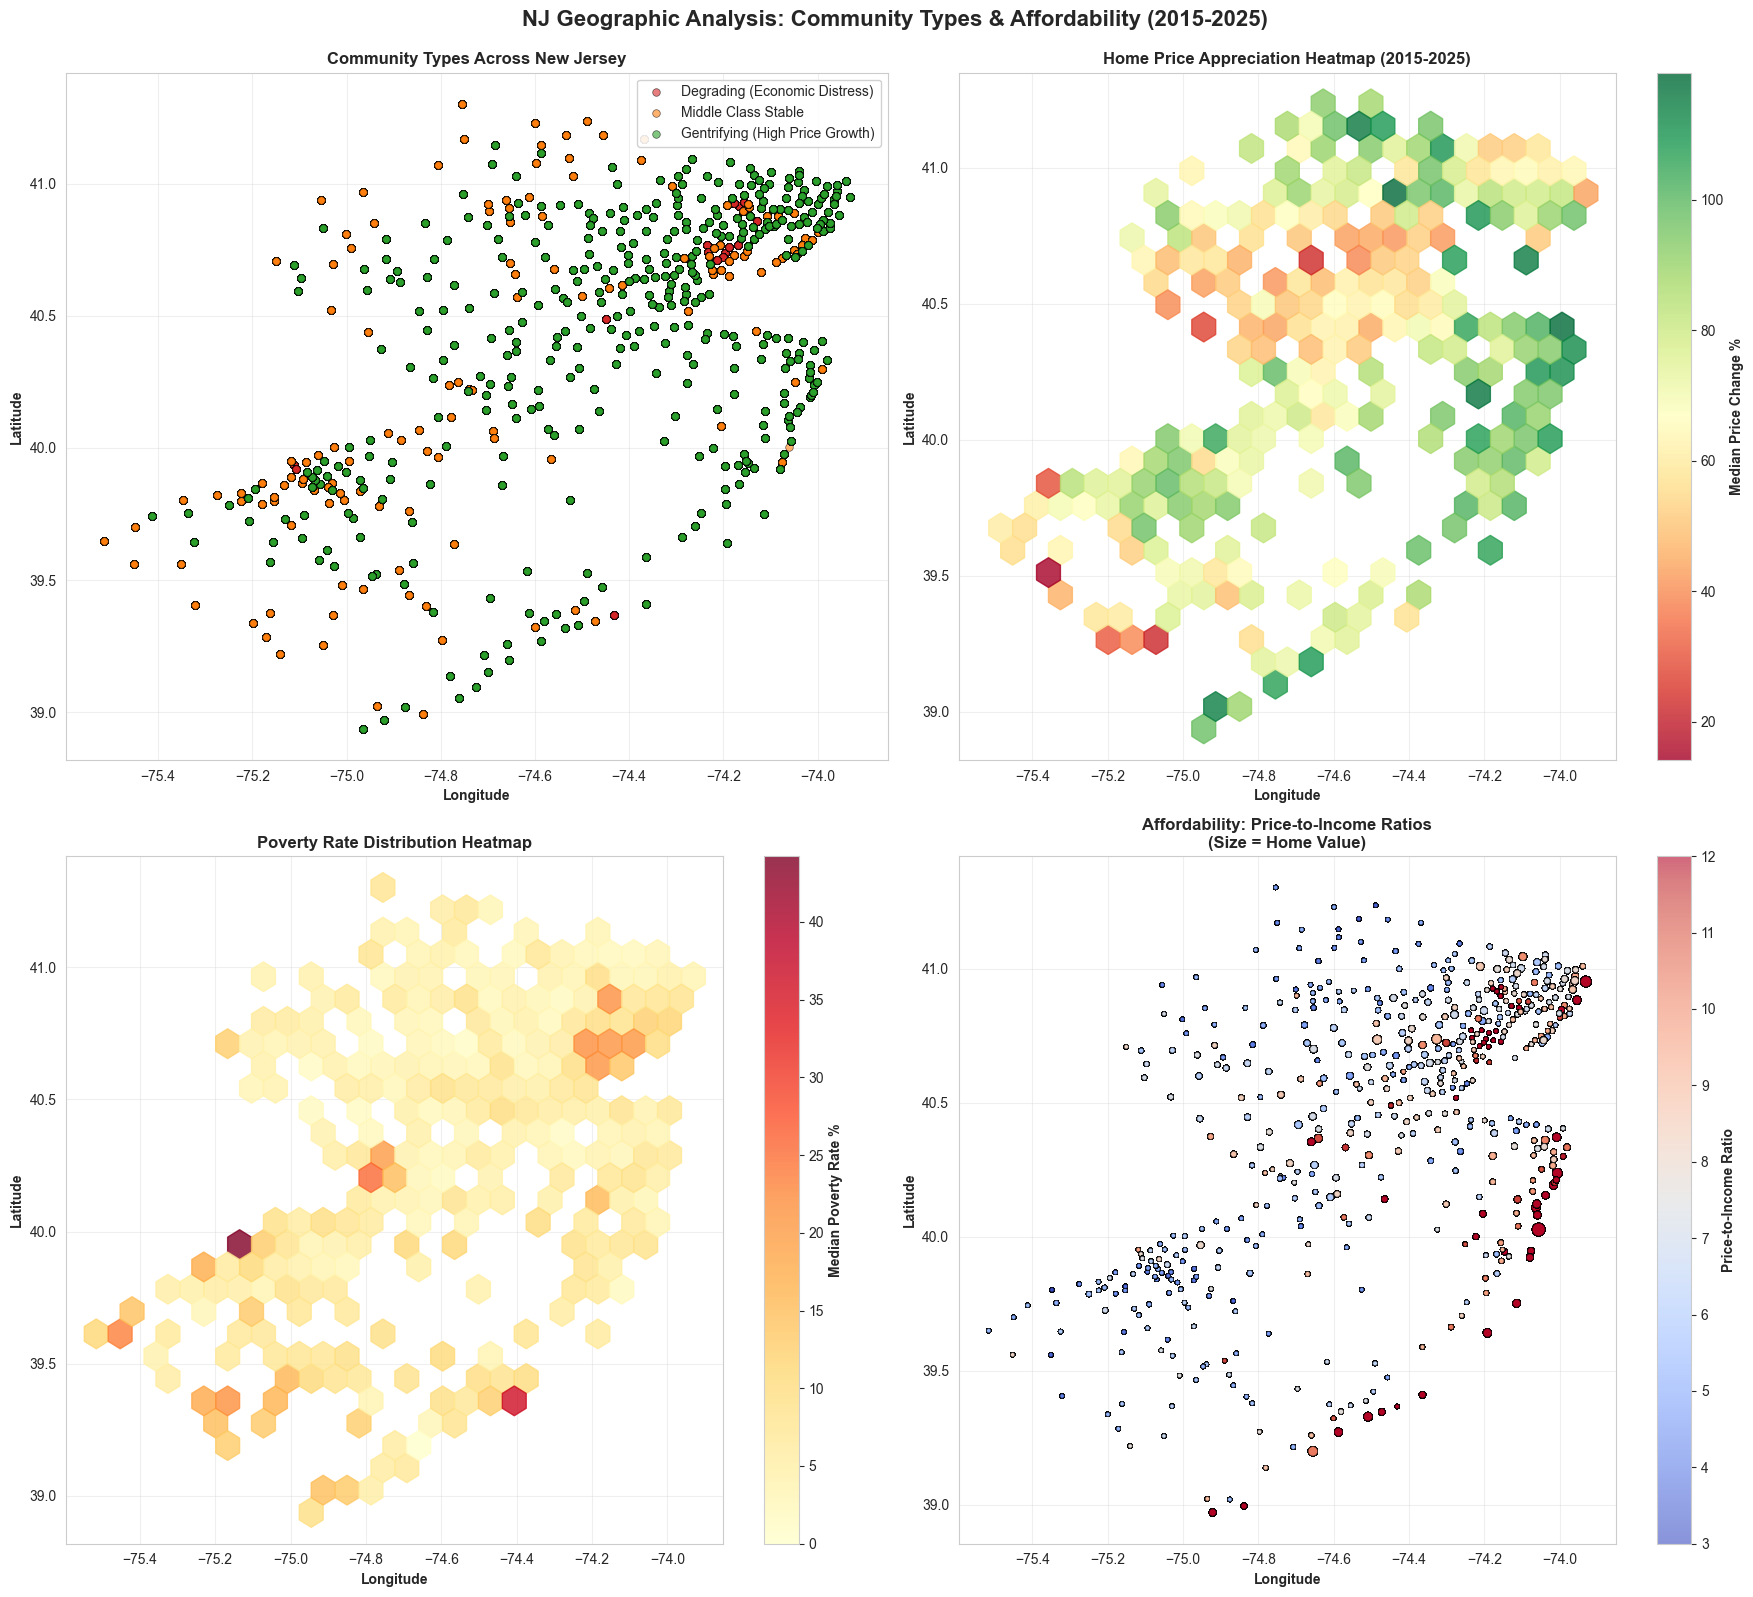

In [11]:
# Create geographic visualizations
fig, axes = plt.subplots(2, 2, figsize=(18, 16))
fig.suptitle('NJ Geographic Analysis: Community Types & Affordability (2015-2025)', 
             fontsize=16, fontweight='bold', y=0.995)

# 1. Community Type Geographic Distribution (Scatterplot)
ax1 = axes[0, 0]
for comm_type, color in PALETTE.items():
    data = comparison_geo[comparison_geo['community_type'] == comm_type]
    ax1.scatter(data['lng'], data['lat'], 
               c=color, label=comm_type, 
               alpha=0.6, s=30, edgecolors='black', linewidth=0.5)

ax1.set_xlabel('Longitude', fontweight='bold')
ax1.set_ylabel('Latitude', fontweight='bold')
ax1.set_title('Community Types Across New Jersey', fontweight='bold', fontsize=12)
ax1.legend(loc='upper right', framealpha=0.9)
ax1.grid(True, alpha=0.3)

# 2. Price Change Heatmap (Hexbin)
ax2 = axes[0, 1]
# Cap extreme values for better visualization
price_data = comparison_geo[
    (comparison_geo['price_change_pct'] >= -20) & 
    (comparison_geo['price_change_pct'] <= 120)
].copy()

hexbin = ax2.hexbin(price_data['lng'], price_data['lat'], 
                    C=price_data['price_change_pct'],
                    gridsize=25, cmap='RdYlGn', 
                    reduce_C_function=np.median,
                    mincnt=1, alpha=0.8)
cb2 = plt.colorbar(hexbin, ax=ax2)
cb2.set_label('Median Price Change %', fontweight='bold')
ax2.set_xlabel('Longitude', fontweight='bold')
ax2.set_ylabel('Latitude', fontweight='bold')
ax2.set_title('Home Price Appreciation Heatmap (2015-2025)', fontweight='bold', fontsize=12)
ax2.grid(True, alpha=0.3)

# 3. Poverty Rate Heatmap
ax3 = axes[1, 0]
poverty_data = comparison_geo.dropna(subset=['poverty_rate'])

hexbin = ax3.hexbin(poverty_data['lng'], poverty_data['lat'],
                    C=poverty_data['poverty_rate'],
                    gridsize=25, cmap='YlOrRd',
                    reduce_C_function=np.median,
                    mincnt=1, alpha=0.8)
cb3 = plt.colorbar(hexbin, ax=ax3)
cb3.set_label('Median Poverty Rate %', fontweight='bold')
ax3.set_xlabel('Longitude', fontweight='bold')
ax3.set_ylabel('Latitude', fontweight='bold')
ax3.set_title('Poverty Rate Distribution Heatmap', fontweight='bold', fontsize=12)
ax3.grid(True, alpha=0.3)

# 4. Price-to-Income Ratio Scatterplot with Size
ax4 = axes[1, 1]
affordability_data = comparison_geo.dropna(subset=['price_to_income_ratio', 'current_home_value'])
# Cap extreme ratios
affordability_data = affordability_data[affordability_data['price_to_income_ratio'] <= 20]

# Size based on home value
sizes = (affordability_data['current_home_value'] / 50000).clip(10, 200)

scatter = ax4.scatter(affordability_data['lng'], affordability_data['lat'],
                     c=affordability_data['price_to_income_ratio'],
                     s=sizes, cmap='coolwarm', alpha=0.6,
                     edgecolors='black', linewidth=0.5,
                     vmin=3, vmax=12)
cb4 = plt.colorbar(scatter, ax=ax4)
cb4.set_label('Price-to-Income Ratio', fontweight='bold')
ax4.set_xlabel('Longitude', fontweight='bold')
ax4.set_ylabel('Latitude', fontweight='bold')
ax4.set_title('Affordability: Price-to-Income Ratios\n(Size = Home Value)', 
             fontweight='bold', fontsize=12)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
Path('visualizations').mkdir(exist_ok=True)
plt.savefig('visualizations/nj_geographic_analysis_2015_2025.png', dpi=300, bbox_inches='tight')
plt.show()
#print("\n📊 Geographic visualization saved: nj_geographic_analysis_2015_2025.png")

## 7. Statistical Visualizations

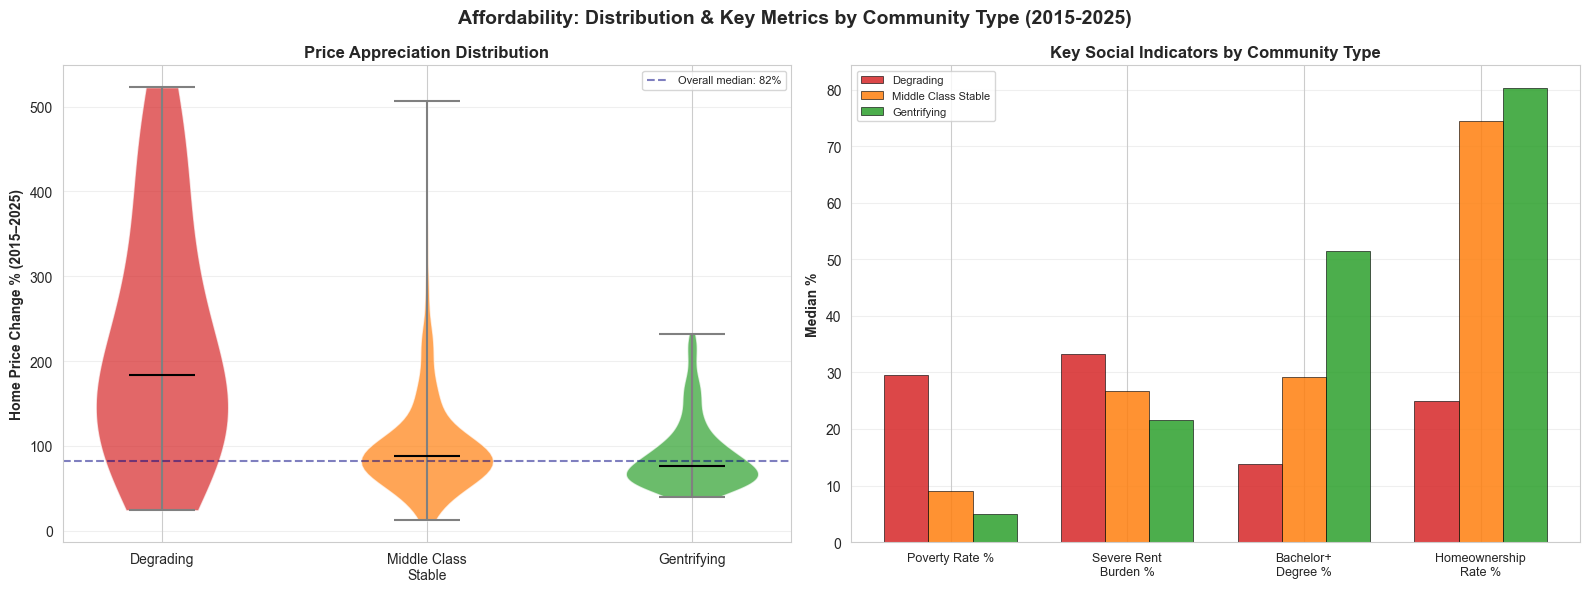

In [12]:
# Deduplicate: one row per ZIP code for clean statistical analysis
comp = comparison.drop_duplicates(subset='zip_code', keep='first').copy()
comp = comp[comp['community_type'].isin(PALETTE.keys())]

# ── Figure 1: Price Distribution & Key Metrics Comparison ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Affordability: Distribution & Key Metrics by Community Type (2015-2025)',
             fontsize=14, fontweight='bold')

# Violin: price change distribution
ax = axes[0]
order = list(PALETTE.keys())
data_list = [comp[comp['community_type'] == ct]['price_change_pct'].dropna() for ct in order]
parts = ax.violinplot(data_list, positions=range(len(order)), showmedians=True, showextrema=True)
for i, (body, ct) in enumerate(zip(parts['bodies'], order)):
    body.set_facecolor(PALETTE[ct])
    body.set_alpha(0.7)
parts['cmedians'].set_color('black')
parts['cmaxes'].set_color('gray')
parts['cmins'].set_color('gray')
parts['cbars'].set_color('gray')
ax.set_xticks(range(len(order)))
ax.set_xticklabels(['Degrading', 'Middle Class\nStable', 'Gentrifying'], fontsize=10)
ax.set_ylabel('Home Price Change % (2015–2025)', fontweight='bold')
ax.set_title('Price Appreciation Distribution', fontweight='bold')
ax.axhline(comp['price_change_pct'].median(), color='navy', linestyle='--', alpha=0.5, label=f'Overall median: {comp["price_change_pct"].median():.0f}%')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

# Bar: multi-metric comparison
ax = axes[1]
metrics = {
    'Poverty Rate %': 'poverty_rate',
    'Severe Rent\nBurden %': 'rent_burden_severe_pct',
    'Bachelor+\nDegree %': 'pct_bachelors_plus',
    'Homeownership\nRate %': 'homeownership_rate',
}
x = np.arange(len(metrics))
width = 0.25
for i, ct in enumerate(order):
    vals = [comp[comp['community_type'] == ct][col].median() for col in metrics.values()]
    bars = ax.bar(x + i * width, vals, width, label=ct.split(' (')[0],
                  color=PALETTE[ct], alpha=0.85, edgecolor='black', linewidth=0.5)
ax.set_xticks(x + width)
ax.set_xticklabels(metrics.keys(), fontsize=9)
ax.set_ylabel('Median %', fontweight='bold')
ax.set_title('Key Social Indicators by Community Type', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('visualizations/stat_viz1_distribution_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Figure 2: Scatter Analysis — Who Gets Priced Out? ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Affordability Pressure: Poverty vs Price-to-Income Ratios (2015-2025)',
             fontsize=14, fontweight='bold')

scatter_data = comp.dropna(subset=['poverty_rate', 'price_to_income_ratio'])
scatter_data = scatter_data[scatter_data['price_to_income_ratio'] <= 20]

# Left: poverty rate vs price-to-income ratio
ax = axes[0]
for ct in order:
    d = scatter_data[scatter_data['community_type'] == ct]
    ax.scatter(d['poverty_rate'], d['price_to_income_ratio'],
               c=PALETTE[ct], label=ct.split(' (')[0],
               alpha=0.55, s=40, edgecolors='none')

ax.axhline(6, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.text(0.5, 6.2, 'Harvard affordability threshold (6×)', fontsize=8, color='gray')
ax.axhline(10, color='darkred', linestyle=':', linewidth=1, alpha=0.7)
ax.text(0.5, 10.2, 'Severe unaffordability (10×)', fontsize=8, color='darkred')
ax.set_xlabel('Poverty Rate %', fontweight='bold')
ax.set_ylabel('Price-to-Income Ratio', fontweight='bold')
ax.set_title('Poverty Rate vs Housing Affordability', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Right: homeownership rate vs severe rent burden
ax = axes[1]
scatter_data2 = comp.dropna(subset=['rent_burden_severe_pct', 'homeownership_rate'])
for ct in order:
    d = scatter_data2[scatter_data2['community_type'] == ct]
    ax.scatter(d['homeownership_rate'], d['rent_burden_severe_pct'],
               c=PALETTE[ct], label=ct.split(' (')[0],
               alpha=0.55, s=40, edgecolors='none')

ax.axvline(50, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.text(51, scatter_data2['rent_burden_severe_pct'].max() * 0.93,
        'Majority renter  |  Majority owner', fontsize=7, color='gray')
ax.set_xlabel('Homeownership Rate %', fontweight='bold')
ax.set_ylabel('Severe Rent Burden % (>50% income on rent)', fontweight='bold')
ax.set_title('Homeownership vs Rent Burden', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('visualizations/stat_viz2_scatter_affordability.png', dpi=150, bbox_inches='tight')
plt.show()

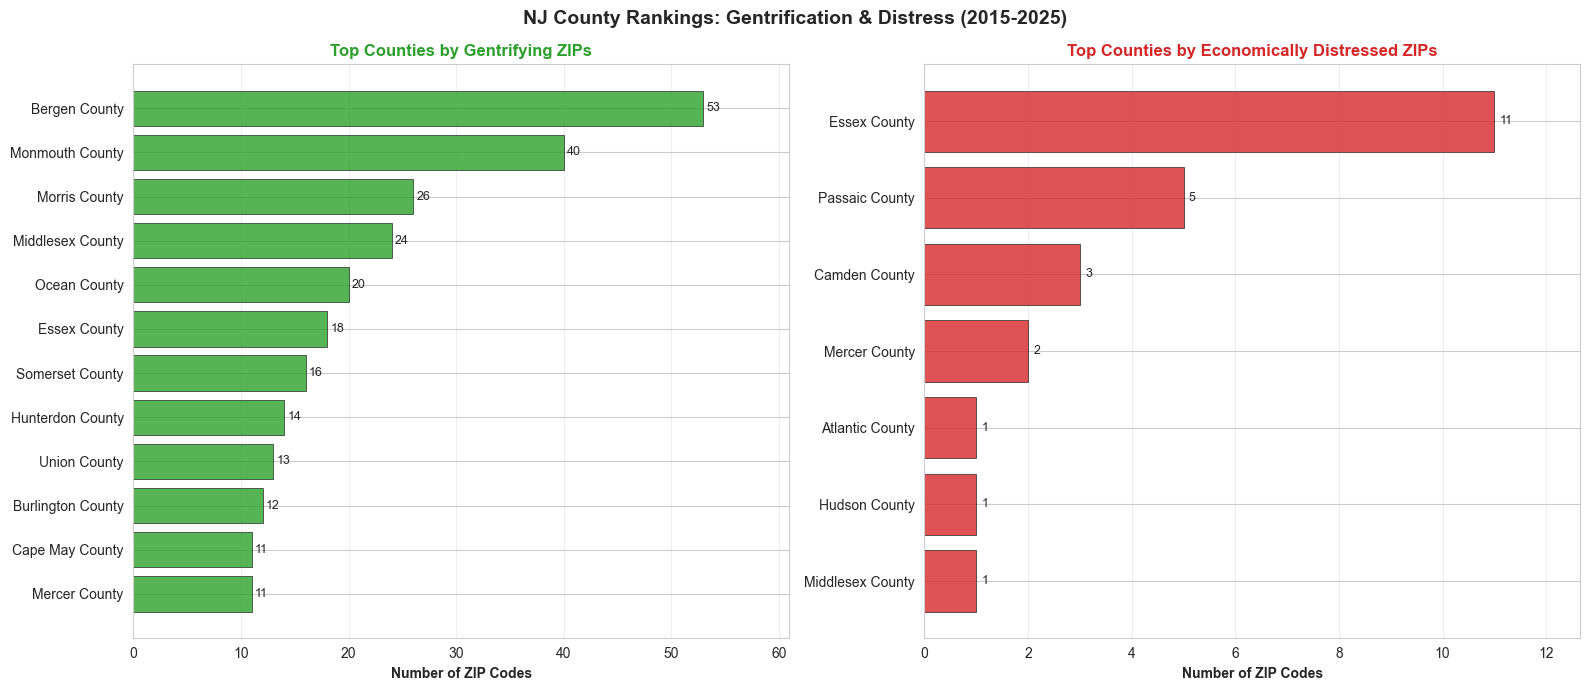

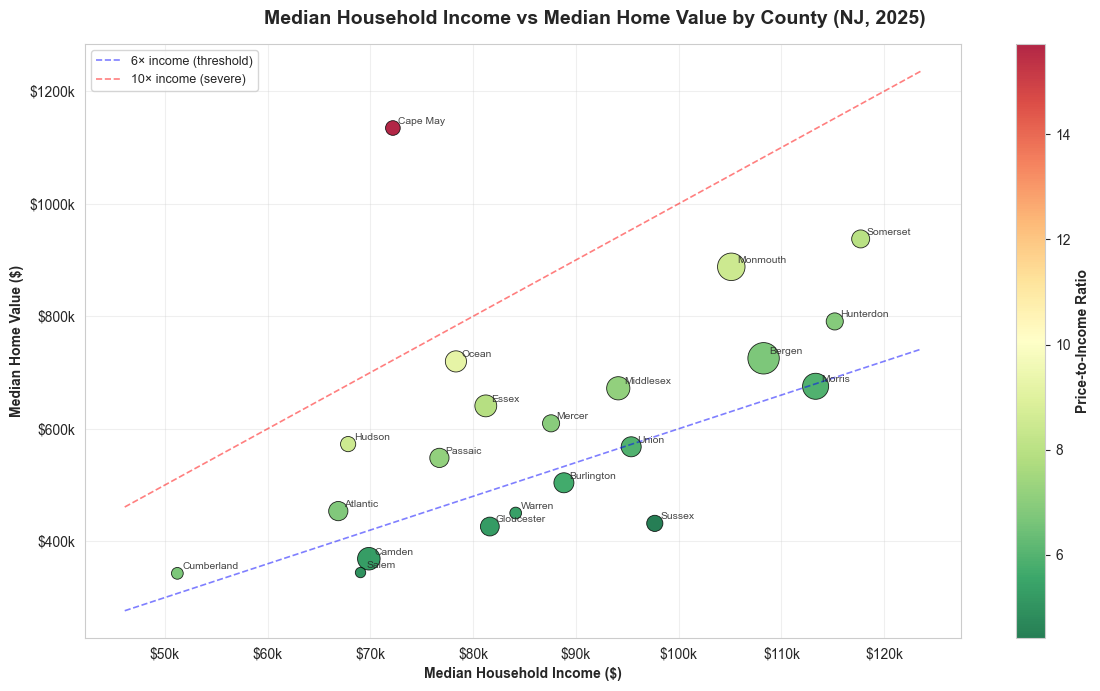

In [13]:
# ── Figure 3: County Rankings — Gentrifying vs Degrading ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('NJ County Rankings: Gentrification & Distress (2015-2025)',
             fontsize=14, fontweight='bold')

gent_counts = (
    comp[comp['community_type'] == 'Gentrifying (High Price Growth)']
    .groupby('county')['zip_code'].count()
    .sort_values(ascending=False)
    .head(12)
)
degrad_counts = (
    comp[comp['community_type'] == 'Degrading (Economic Distress)']
    .groupby('county')['zip_code'].count()
    .sort_values(ascending=False)
    .head(12)
)

ax = axes[0]
bars = ax.barh(gent_counts.index[::-1], gent_counts.values[::-1],
               color='#2ca02c', alpha=0.8, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, gent_counts.values[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontsize=9)
ax.set_xlabel('Number of ZIP Codes', fontweight='bold')
ax.set_title('Top Counties by Gentrifying ZIPs', fontweight='bold', color='#2ca02c')
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0, gent_counts.max() * 1.15)

ax = axes[1]
bars = ax.barh(degrad_counts.index[::-1], degrad_counts.values[::-1],
               color='#d62728', alpha=0.8, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, degrad_counts.values[::-1]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontsize=9)
ax.set_xlabel('Number of ZIP Codes', fontweight='bold')
ax.set_title('Top Counties by Economically Distressed ZIPs', fontweight='bold', color='#d62728')
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0, degrad_counts.max() * 1.15)

plt.tight_layout()
plt.savefig('visualizations/stat_viz3_county_rankings.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 4: Median Income vs Home Value by County ────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))
fig.suptitle('Median Household Income vs Median Home Value by County (NJ, 2025)',
             fontsize=14, fontweight='bold')

county_stats = (
    comp.dropna(subset=['income_median_hh', 'current_home_value'])
    .groupby('county')
    .agg(med_income=('income_median_hh', 'median'),
         med_home=('current_home_value', 'median'),
         n_zips=('zip_code', 'count'))
    .reset_index()
)

scatter = ax.scatter(
    county_stats['med_income'], county_stats['med_home'],
    s=county_stats['n_zips'] * 8,
    c=county_stats['med_home'] / county_stats['med_income'],
    cmap='RdYlGn_r', alpha=0.85, edgecolors='black', linewidth=0.6
)
cb = plt.colorbar(scatter, ax=ax)
cb.set_label('Price-to-Income Ratio', fontweight='bold')

for _, row in county_stats.iterrows():
    label = row['county'].replace(' County', '')
    ax.annotate(label, (row['med_income'], row['med_home']),
                fontsize=7.5, xytext=(4, 3), textcoords='offset points', alpha=0.85)

x_range = np.linspace(county_stats['med_income'].min() * 0.9,
                      county_stats['med_income'].max() * 1.05, 100)
ax.plot(x_range, x_range * 6, 'b--', linewidth=1.2, alpha=0.5, label='6× income (threshold)')
ax.plot(x_range, x_range * 10, 'r--', linewidth=1.2, alpha=0.5, label='10× income (severe)')
ax.legend(fontsize=9)
ax.set_xlabel('Median Household Income ($)', fontweight='bold')
ax.set_ylabel('Median Home Value ($)', fontweight='bold')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('visualizations/stat_viz4_income_vs_home_value.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Export Results

## 9. Close Connection

## 7. Close Connection

In [10]:
# Close database connection
conn.close()
print("\n✅ Analysis complete. Database connection closed.")


✅ Analysis complete. Database connection closed.
